<h1 align="left">Channels and NDVI Experimentation</h1>

<p align="left"><i>PASTIS24 Dataset</i></p>

<p align="left">
  ITESM
  
  <a href="https://www.linkedin.com/in/juanrtato/">Juan Ricardo Albarracin B.</a>
  <br>
  <a href="">Luis Ángel Oporto Añacato.</a>
  <br>
  <a href="">David Alexis García Espinosa.</a>
  <br>
  <b>Last updated:</b> <i>01/06/2025</i>
  <br><br>
  <a target="_blank">
    <img src="https://github.com/QData/TextAttack/workflows/Github%20PyTest/badge.svg" alt="Testing">
  </a>
  <a href="https://img.shields.io/badge/version-0.1.0-blue.svg?cacheSeconds=2592000">
    <img src="https://img.shields.io/badge/version-0.1.0-blue.svg?cacheSeconds=2592000" alt="Version" height="18">
  </a>
</p><br>

In [1]:
PATH_TO_PASTIS = '../datalake/PASTIS24'
PATH_TO_CODE = '../scripts/pastis24'
PATH_TO_FOLDS = '../datalake/PASTIS24/fold-paths'
PATH_TO_PICKLES = '../datalake/PASTIS24/pickle24X24'
CONFIG_PATH = '../datalake/config_vtt.json'
METADATA_PATH = '../datalake/PASTIS24/metadata.geojson'

In [2]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..', 'scripts')))
#sys.path.append(PATH_TO_CODE)

In [3]:
import ast
import json
import re
import random
from datetime import datetime, timedelta
from itertools import islice
import plotly.express as px
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import torch
import pastis24
from pastis24 import get_dataloaders

from utils import plot_sample_rgb, plot_seg_mask, plot_mean_band_profile, calculate_ndvi_by_crop

In [4]:
with open(METADATA_PATH, 'r') as f:
    metadata_json = json.load(f)

In [5]:
with open(CONFIG_PATH, 'r') as f:
    config = json.load(f)

In [6]:
with open("../datalake/label_names_en.json", "r") as json_file:
    label_names_en = json.load(json_file)

In [7]:
with open("../datalake/colormap.txt", "r") as txt_file:
    colormap = txt_file.readlines()
colormap = [ast.literal_eval(line.strip().rstrip(',')) for line in colormap]

In [8]:
config['DATASETS']['eval']['normalize'] = False
config['DATASETS']['train']['normalize'] = False


In [9]:
data = []
for feature in metadata_json["features"]:
    properties = feature["properties"]
    data.append(properties)

metadata_df = pd.DataFrame(data)
metadata_df.head()

,Fold,ID_PATCH,N_Parcel,Parcel_Cover,TILE,dates-S2,id
0,1,10000,119,0.808032,t30uxv,"{'0': 20180924, '1': 20180929, '2': 20181004, ...",10000
1,2,10001,111,0.501986,t30uxv,"{'0': 20180924, '1': 20180929, '2': 20181004, ...",10001
2,4,10002,131,0.638722,t30uxv,"{'0': 20180924, '1': 20180929, '2': 20181004, ...",10002
3,5,10003,75,0.866824,t30uxv,"{'0': 20180924, '1': 20180929, '2': 20181004, ...",10003
4,4,10004,46,0.204906,t30uxv,"{'0': 20180924, '1': 20180929, '2': 20181004, ...",10004


In [10]:
dataloaders = get_dataloaders(config)

Loading PASTIS2SEQUENCE dataset...
PASTIS2SEQUENCE dataset loaded!


../datalake/PASTIS24/pickle24x24/30460_10.pickle
<re.Match object; span=(0, 15), match='30460_10.pickle'>
Sample shape: (60, 24, 24, 11)
Sample labels shape: (24, 24, 1)


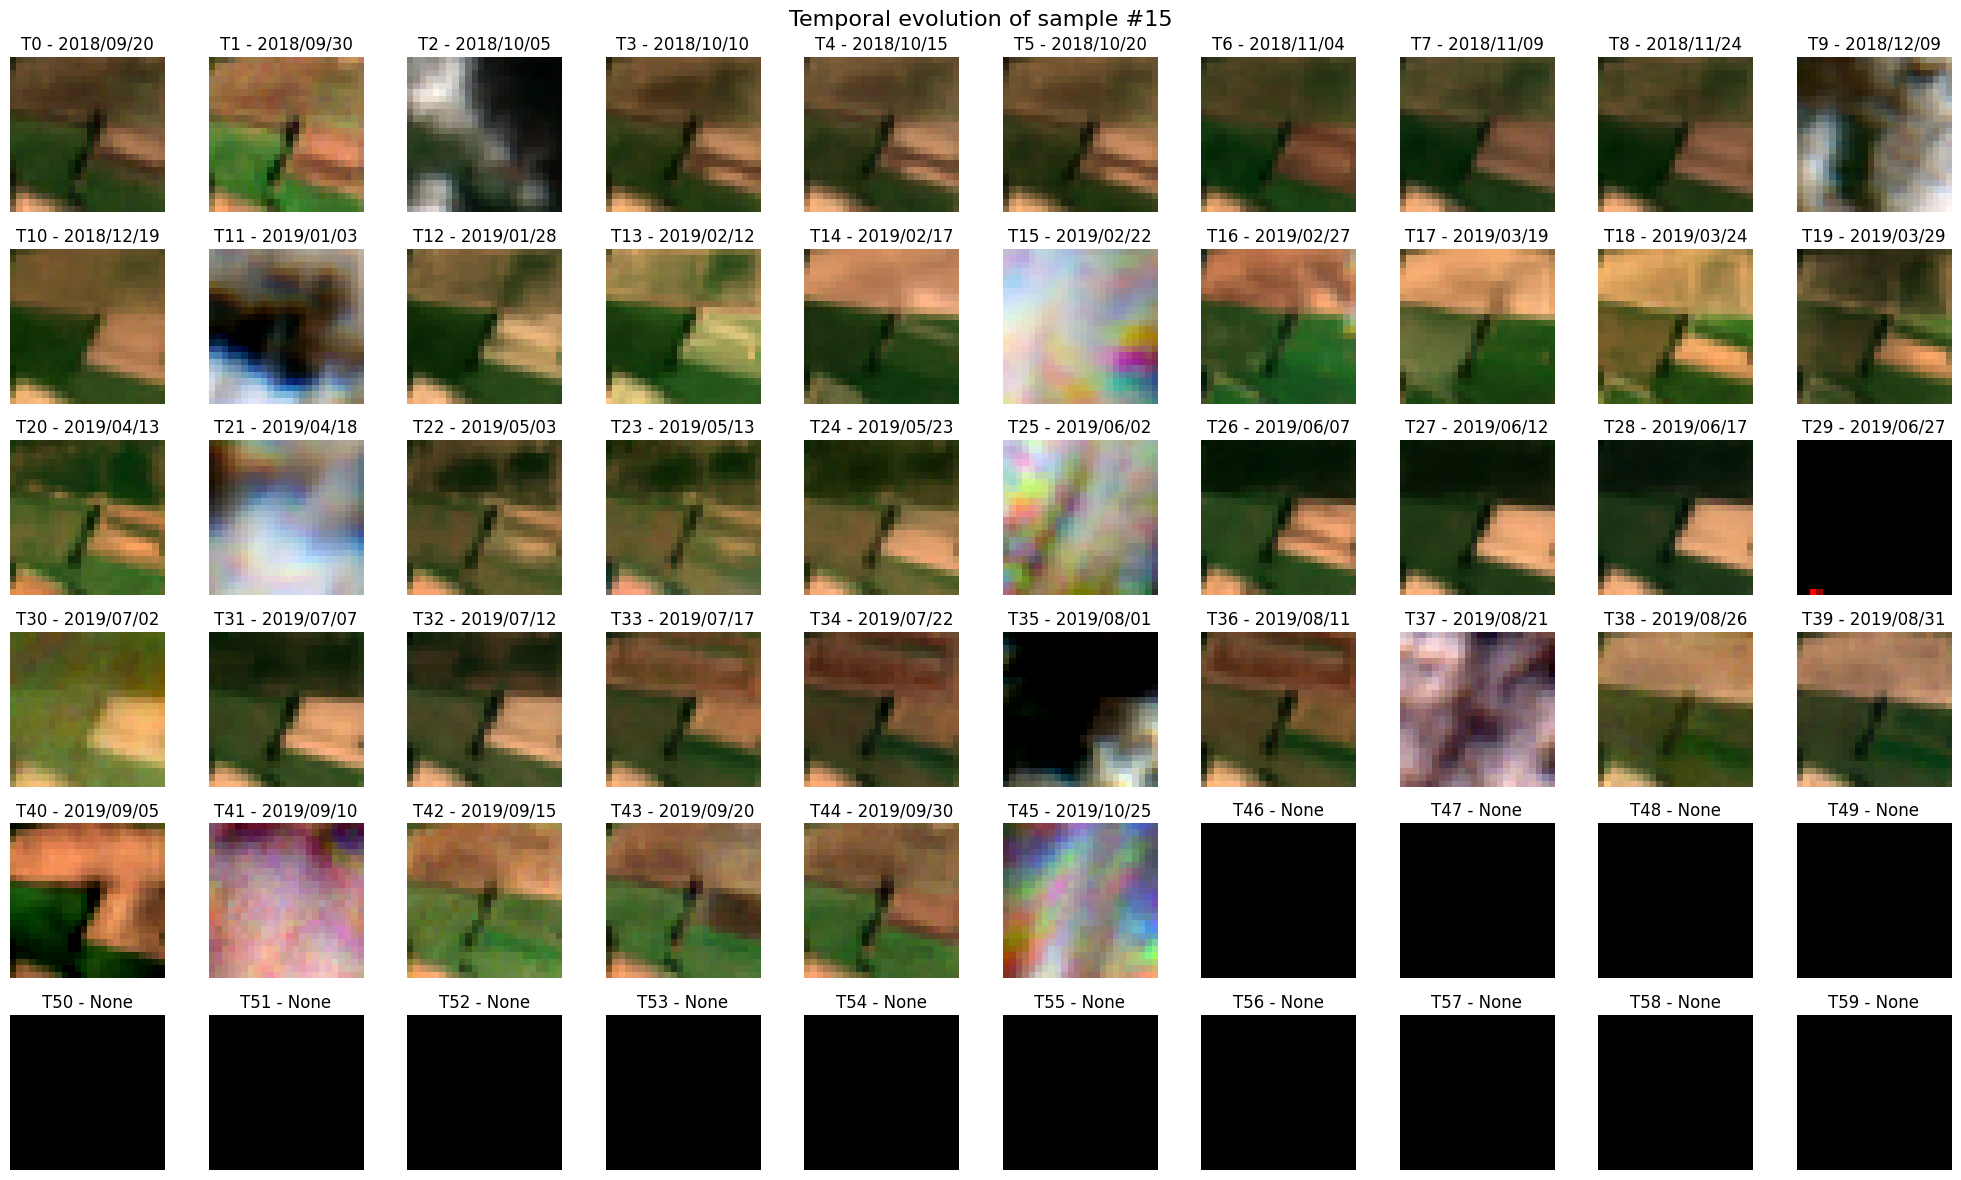

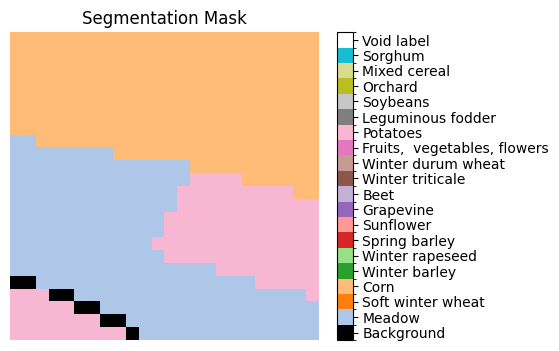

In [11]:
sample = next(iter(dataloaders['eval']))
sample_dict, texts, img_path = sample
sample_idx = random.randint(0, 16)
patch_id = 'UNKNOWN'
inputs = sample_dict['inputs']
labels = sample_dict['labels']
path_patch = img_path[sample_idx]
print(path_patch)
match = re.match(r"(\d+)_\d+\.pickle", os.path.basename(path_patch))
print(match)
if match:
    patch_id = match.group(1)
sample_labels = labels[15]
plot_sample_rgb(inputs, labels, patch_id, sample_idx=15)
plot_seg_mask(sample_labels[:, :, 0], colormap, label_names_en)

In [14]:
print(texts[sample_idx])

The image shows a cultivated area of Meadow with an estimated size of 29700 m2, Winter barley with a coverage of approximately 12500 m2, which forms an essential part of the total agricultural area. 


Looking at the planting and harvest schedules, It seems that Meadow was cultivated starting in 5, with harvest expected in 18. On top of that, the crop Winter barley had a planting period starting in 5, with harvesting occurring in 17.


## Bands (channels) analysis

Plot the mean value of pixel per band given a specific sample:

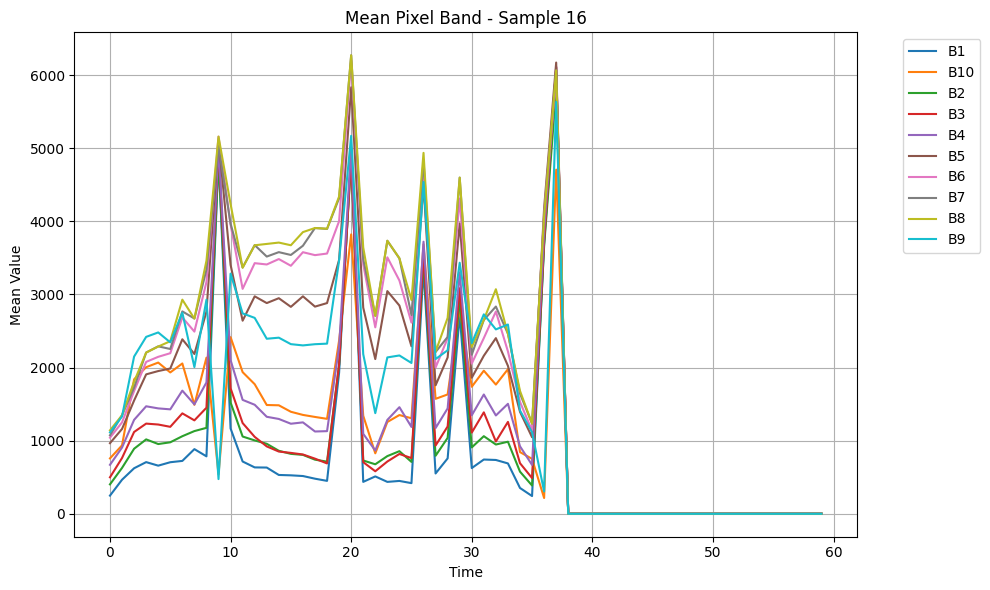

In [901]:
plot_mean_band_profile(inputs, sample_idx=sample_idx)

## NDVI

**NDVI** (Normalized Difference Vegetation Index) is an index used to assess the amount and health of vegetation on the Earth's surface using satellite images or remote sensing data.


NDVI is calculated using the **red (Red)** and **near-infrared (NIR)** bands of the satellite image. The formula is:

$$
NDVI = \frac{(NIR - Red)}{(NIR + Red)}
$$


NDVI is a value ranging from **-1 to +1**, where:

- **Values close to +1** (for example, between 0.6 and 0.9) indicate **dense and healthy vegetation**.
- **Values close to 0** (for example, between 0.0 and 0.2) indicate **areas with little or no vegetation**, such as bare soil, rocks, or urban areas.
- **Negative values** are typically associated with **non-vegetated surfaces** like water, snow, or clouds.

- NDVI allows scientists and farmers to monitor vegetation status and crop health remotely.
- It is useful for detecting changes in land cover and vegetation over time.
- NDVI can also be an early indicator of drought, as vegetation tends to reduce its photosynthetic activity under dry conditions.


In [902]:
def calculate_ndvi(inputs, sample_idx):
    """
    Function to calculate NDVI from the input tensor.
    The input tensor is expected to have the shape [T, H, W, B],
    where T is the number of time steps, H is the height, W is the width,
    and B is the number of bands.
    The NDVI is calculated using the formula:
    NDVI = (NIR - Red) / (NIR + Red)
    where NIR is the value of the NIR band and Red is the value of the Red band.
    The NIR band is assumed to be at index 6 and the Red band at index 7.
    The function returns a tensor with the NDVI values for each time step.
    Args:
        inputs (torch.Tensor): Input tensor of shape [T, H, W, B].
        sample_idx (int): Index of the sample to calculate NDVI for.
    Returns:
        torch.Tensor: Tensor with the NDVI values for each time step.
    """
    sample = inputs[sample_idx]  # shape: [T, H, W, B]
    num_times = sample.shape[0]

    ndvi_values = []

    for t_index in range(num_times):
        nir_band = sample[t_index, :, :, 6] / 10000.0  # B08 → NIR
        red_band = sample[t_index, :, :, 2] / 10000.0  # B04 → Red

        ndvi = (nir_band - red_band) / (nir_band + red_band + 1e-6)
        ndvi_values.append(ndvi)

    return torch.stack(ndvi_values)  # [T, H, W] # Tensor with the NDVI values for each time step

ndvi_tensor = calculate_ndvi(inputs, sample_idx=sample_idx)

In [903]:
ndvi_tensor.shape

torch.Size([60, 24, 24])

In [904]:
print("NDVI min:", ndvi_tensor.min().item())
print("NDVI max:", ndvi_tensor.max().item())

NDVI min: -0.968917191028595
NDVI max: 1.7617847919464111


In [905]:
def plot_ndvi_map_with_mask(ndvi_tensor, mask, time_index=0, sample_idx=None):
    """
    Plots the NDVI image at a given time index, showing only pixels where a crop is present.

    Args:
        ndvi_tensor (torch.Tensor): NDVI tensor with shape [T, H, W].
        mask (torch.Tensor): Crop mask with shape [H, W], where 0 = background/void.
        time_index (int): Time step to visualize.
        sample_idx (int, optional): Sample index for the title.
    """
    ndvi_image = ndvi_tensor[time_index].cpu().numpy()
    mask_np = mask.cpu().numpy()

    # Mask NDVI where there is no crop
    masked_ndvi = np.where(mask_np > 0, ndvi_image, np.nan)

    plt.figure(figsize=(3, 3))
    plt.imshow(masked_ndvi, cmap='RdYlGn', vmin=-0.1, vmax=1)
    plt.colorbar(label='NDVI')
    title = f"NDVI Map - Time {time_index}"
    if sample_idx is not None:
        title += f" (Sample {sample_idx})"
    plt.title(title)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

In [906]:
ndvi_tensor_by_crop = calculate_ndvi_by_crop(inputs[sample_idx], sample_labels=sample_labels[:, :, 0], label_dict=label_names_en)

In [907]:
def plot_ndvi_by_crop(ndvi_by_crop, sample_idx):
    """
    Plots the temporal NDVI evolution for each crop type present in a sample.

    Args:
        ndvi_by_crop (dict): Dictionary {crop_name: NDVI tensor [T]}.
        sample_idx (int): Index of the sample, used for the plot title.
    """
    plt.figure(figsize=(12, 7))
    
    for crop_name, ndvi_series in ndvi_by_crop.items():
        ndvi_values = ndvi_series.cpu().numpy()  # convert to NumPy if on GPU
        plt.plot(range(len(ndvi_values)), ndvi_values, label=crop_name)
    
    plt.title(f"NDVI Temporal Evolution by Crop Type - Sample {sample_idx}")
    plt.xlabel("Time")
    plt.ylabel("Mean NDVI")
    plt.grid(True)
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))  # move legend outside
    plt.tight_layout()
    plt.show()

In [908]:
ndvi_tensor_by_crop

{'2': tensor([ 0.1828,  0.1850,  0.1789,  0.3013,  0.4399,  0.5410,  0.5688,  0.3984,
          0.7758,  0.0120,  0.4644,  0.6823,  0.5261,  0.4923,  0.2938,  0.2376,
          0.2173,  0.1877,  0.0943,  0.1499,  0.2362,  0.1580,  0.2938,  0.2155,
          0.2598,  0.4483,  0.1155,  0.2309,  0.2564,  0.1902,  0.2247,  0.1967,
          0.4346,  0.1917,  0.2162,  0.1679, -0.0135,  0.0036,     nan,     nan,
             nan,     nan,     nan,     nan,     nan,     nan,     nan,     nan,
             nan,     nan,     nan,     nan,     nan,     nan,     nan,     nan,
             nan,     nan,     nan,     nan]),
 '12': tensor([0.2940, 0.1858, 0.1557, 0.1688, 0.1950, 0.2041, 0.2616, 0.2434, 0.3217,
         0.0132, 0.3788, 0.4088, 0.4714, 0.4955, 0.5189, 0.5320, 0.5415, 0.5449,
         0.4306, 0.3913, 0.1537, 0.3625, 0.4007, 0.4077, 0.4048, 0.4520, 0.1228,
         0.2116, 0.2624, 0.1718, 0.1731, 0.2237, 0.4680, 0.2406, 0.3206, 0.3479,
         0.0316, 0.0024,    nan,    nan,    nan,   

In [909]:
def detect_clouds(inputs, sample_idx, blue_idx=0, swir1_idx=8, swir2_idx=9,
                  blue_thresh=0.2, swir_thresh=0.15):
    """
    Detecta en qué pasos de tiempo hay nubes para un sample y devuelve una máscara booleana.

    Args:
        inputs (torch.Tensor): Tensor [num_samples, T, H, W, B]
        sample_idx (int): Índice del sample a analizar

    Returns:
        np.ndarray: Máscara booleana de tamaño [T] con True si hay nubes en ese tiempo.
    """
    sample = inputs[sample_idx]  # [T, H, W, B]
    T = sample.shape[0]
    ndvi = calculate_ndvi(inputs, sample_idx)  # [T]
    cloud_mask_by_time = np.zeros(T, dtype=bool)

    for t in range(T):
        blue = sample[t, :, :, blue_idx] / 10000.0
        swir1 = sample[t, :, :, swir1_idx] / 10000.0
        swir2 = sample[t, :, :, swir2_idx] / 10000.0

        cloud_pixel_mask = (blue > blue_thresh) & (swir1 > swir_thresh) & (swir2 > swir_thresh)

        if cloud_pixel_mask.any() or (ndvi[t].mean() < 0.1):
            cloud_mask_by_time[t] = True

    return cloud_mask_by_time


In [ ]:
def clean_crop_times(inputs, sample_idx, sample_labels):
    """
    Limpia la serie temporal de NDVI asignando NaN a valores inválidos (<0.2 o nubes).
    
    Args:
        inputs (torch.Tensor): Tensor [num_samples, T, H, W, B]
        crop_to_sample_idx (dict): {crop_name: sample_idx in inputs}
        sample_idx (int): Sample index to clean.

    Returns:
        dict: Dictionary with cleaned NDVI tensors:
        {
            'crop_name': cleaned NDVI tensor with invalid values set to NaN
            
        }
    """
    ndvi_by_crop = calculate_ndvi_by_crop(inputs[sample_idx], sample_labels)
    cleaned_data = {}

    for crop_name, ndvi_series in ndvi_by_crop.items():
        cloud_mask = detect_clouds(inputs, sample_idx)  # [T]
        ndvi_values = ndvi_series.cpu().numpy()

        
        
        valid_ndvi_mask = (ndvi_values >= 0.21)
        valid_mask = valid_ndvi_mask & ~cloud_mask  # NDVI válido y sin nubes

        cleaned_ndvi = ndvi_values.copy()
        cleaned_ndvi[~valid_mask] = np.nan
        cleaned_data[crop_name] = torch.tensor(cleaned_ndvi)

    return cleaned_data

print("Input shape:", inputs.shape)
cleaned_ndvi_by_crop = clean_crop_times(inputs, sample_idx, sample_labels=sample_labels[:, :, 0])


Input shape: torch.Size([24, 60, 24, 24, 11])


In [918]:
cleaned_ndvi_by_crop

{'2': tensor([   nan,    nan,    nan, 0.3013, 0.4399, 0.5410, 0.5688, 0.3984, 0.7758,
            nan, 0.4644, 0.6823, 0.5261, 0.4923, 0.2938, 0.2376, 0.2173,    nan,
            nan,    nan,    nan,    nan, 0.2938, 0.2155, 0.2598, 0.4483,    nan,
         0.2309, 0.2564,    nan, 0.2247,    nan, 0.4346,    nan, 0.2162,    nan,
            nan,    nan,    nan,    nan,    nan,    nan,    nan,    nan,    nan,
            nan,    nan,    nan,    nan,    nan,    nan,    nan,    nan,    nan,
            nan,    nan,    nan,    nan,    nan,    nan]),
 '12': tensor([0.2940,    nan,    nan,    nan,    nan,    nan, 0.2616, 0.2434, 0.3217,
            nan, 0.3788, 0.4088, 0.4714, 0.4955, 0.5189, 0.5320, 0.5415, 0.5449,
         0.4306,    nan,    nan, 0.3625, 0.4007, 0.4077, 0.4048, 0.4520,    nan,
         0.2116, 0.2624,    nan,    nan, 0.2237, 0.4680, 0.2406, 0.3206, 0.3479,
            nan,    nan,    nan,    nan,    nan,    nan,    nan,    nan,    nan,
            nan,    nan,    nan,    nan

Sample shape: (60, 24, 24, 11)
Sample labels shape: (24, 24, 1)


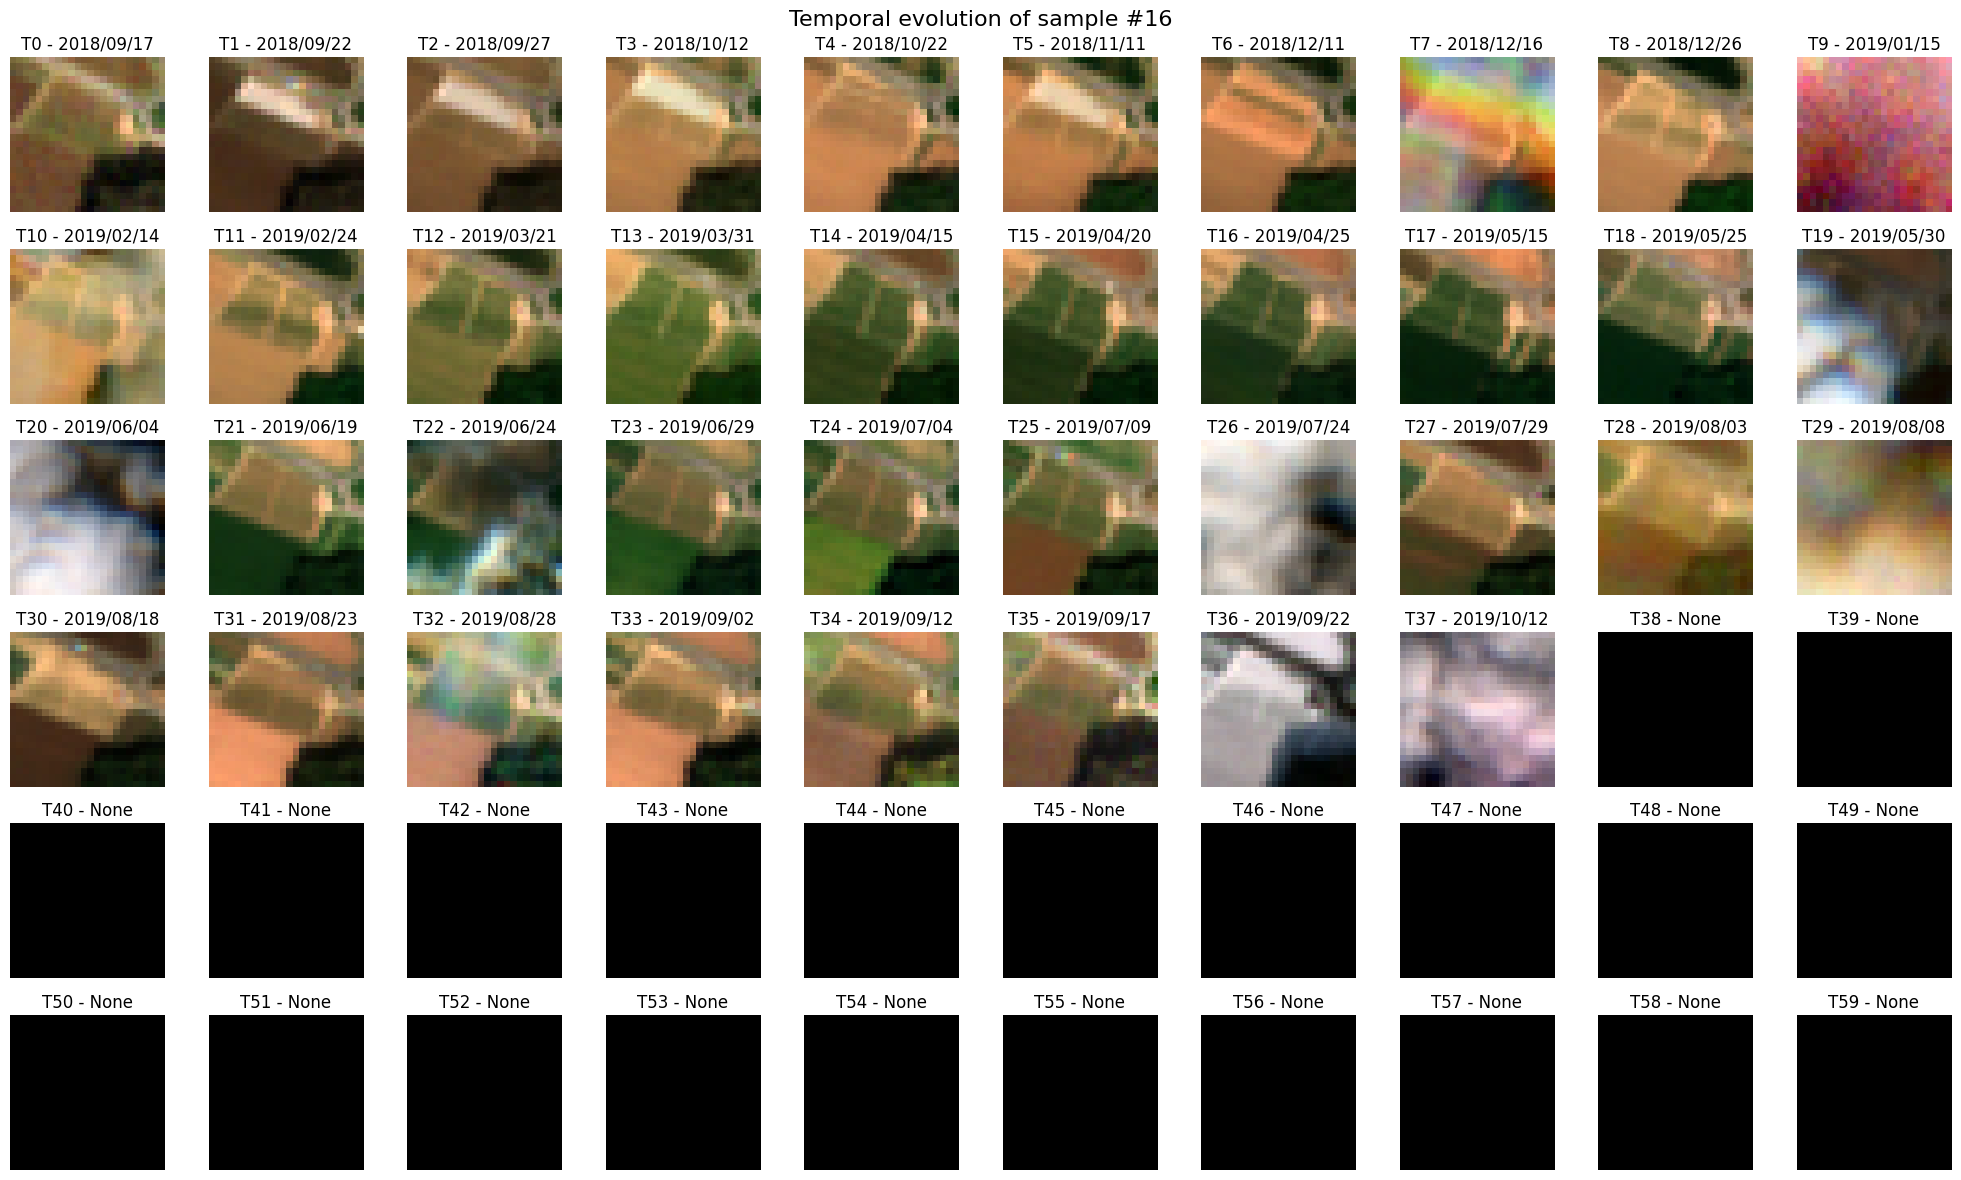

In [912]:
plot_sample_rgb(inputs, labels, patch_id, sample_idx=sample_idx)

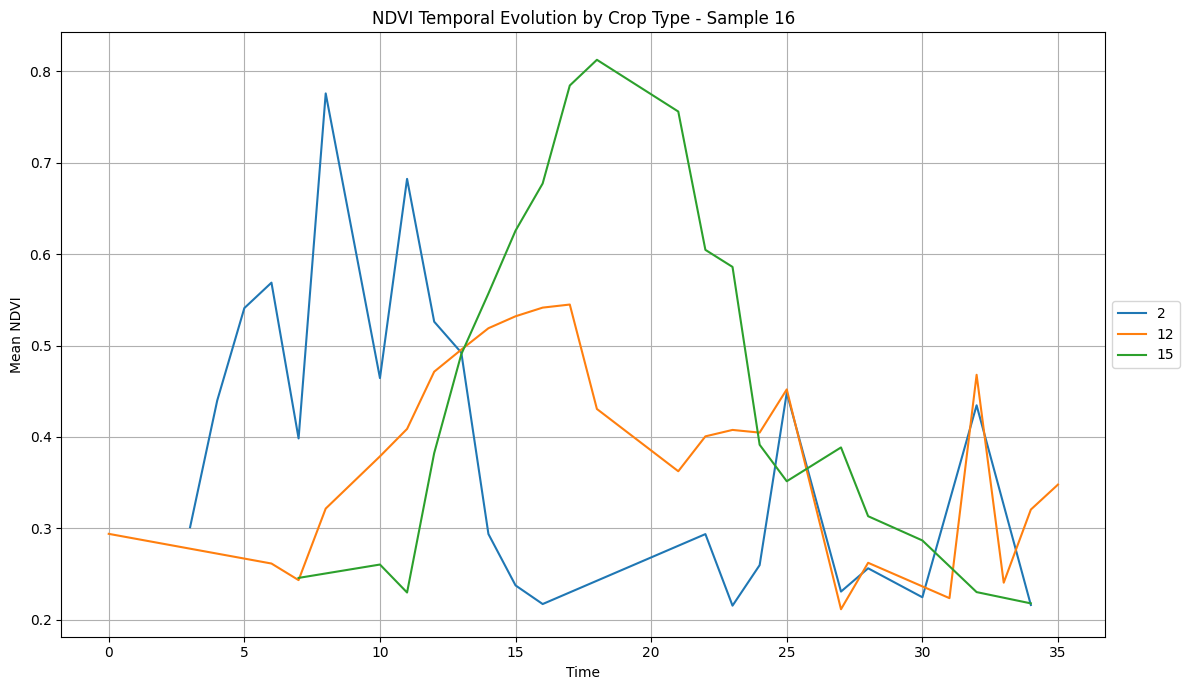

In [913]:
def plot_ndvi_by_crop(ndvi_by_crop, sample_idx):
    """
    Plots the temporal NDVI evolution for each crop type, skipping NaNs so the curve is continuous.

    Args:
        ndvi_by_crop (dict): {crop_name: NDVI tensor [T]}.
        sample_idx (int): Sample index for the plot title.
    """
    plt.figure(figsize=(12, 7))
    
    for crop_name, ndvi_series in ndvi_by_crop.items():
        ndvi_values = ndvi_series.cpu().numpy()
        x = np.arange(len(ndvi_values))
        
        # Only plot valid (non-NaN) points
        valid_mask = ~np.isnan(ndvi_values)
        plt.plot(x[valid_mask], ndvi_values[valid_mask], label=crop_name)

    plt.title(f"NDVI Temporal Evolution by Crop Type - Sample {sample_idx}")
    plt.xlabel("Time")
    plt.ylabel("Mean NDVI")
    plt.grid(True)
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.tight_layout()
    plt.show()
plot_ndvi_by_crop(cleaned_ndvi_by_crop, sample_idx=sample_idx)

In [ ]:
def merge_periods(periods):
    if not periods:
        return []
    merged = []
    # Ordenar por start_idx, ignorando 'unknown' que va primero
    periods = sorted(periods, key=lambda x: (float('-inf') if x[0] == "unknown" else x[0]))
    current_start, current_end = periods[0]
    for start, end in periods[1:]:
        # Solo fusionar si ambos índices son números (no "unknown") y si se tocan o solapan
        if current_end == start or (isinstance(current_end, int) and isinstance(start, int) and start <= current_end):
            # Fusionar extendiendo el fin
            if isinstance(end, int) and (not isinstance(current_end, int) or end > current_end):
                current_end = end
        else:
            merged.append((current_start, current_end))
            current_start, current_end = start, end
    merged.append((current_start, current_end))
    return merged

In [ ]:
def estimate_planting_harvest_periods_by_crop(ndvi_by_crop, delta_thresh_start=0.05, delta_thresh_end=0.05, min_duration=3):
    """
    Detecta múltiples periodos de siembra y cosecha para cada tipo de cultivo,
    incluyendo detección de cosechas al inicio sin siembra visible.

    Args:
        ndvi_by_crop (dict): {crop_name: NDVI tensor [T]} (puede contener NaNs).
        delta_thresh_start (float): Umbral mínimo de subida para considerar siembra.
        delta_thresh_end (float): Umbral mínimo de bajada para considerar cosecha.
        min_duration (int): Duración mínima esperada entre siembra y cosecha.

    Returns:
        dict: {crop_name: [(start_idx, end_idx)]} solo el periodo con mayor mean NDVI.
               Si no se detecta ningún periodo válido, lista vacía.
    """
    crop_periods = {}

    for crop_name, ndvi_tensor in ndvi_by_crop.items():
        ndvi = ndvi_tensor.cpu().numpy()
        mean_ndvi = np.nanmean(ndvi)
        if mean_ndvi <= 0.35:
            crop_periods[crop_name] = []
            continue
        valid_mask = ~np.isnan(ndvi)
        valid_indices = np.where(valid_mask)[0]
        valid_values = ndvi[valid_mask]

        if len(valid_values) < 3:
            crop_periods[crop_name] = []
            continue

        deltas = np.diff(valid_values)
        periods = []
        dict_periods = {}

        # Detectar posible cosecha al inicio sin siembra visible
        print(f"First ndvi: {ndvi[0]}")
        if deltas[0] < -delta_thresh_end:
            if ndvi[0] >= 0.6:
                periods.append(("unknown", valid_indices[1]))
                dict_periods[("unknown", valid_indices[1])] = ndvi[0]

        i = 0
        while i < len(deltas):
            if deltas[i] > delta_thresh_start:
                start_idx = valid_indices[i]
                for j in range(i + min_duration, len(deltas)):
                    if deltas[j] < -delta_thresh_end:
                        end_idx = valid_indices[j + 1]
                        mean_ndvi_period = np.nanmean(ndvi[start_idx:end_idx])
                        dict_periods[(start_idx, end_idx)] = mean_ndvi_period
                        periods.append((start_idx, end_idx))
                        i = j + 1
                        #break
                else:
                    i += 1
            else:
                i += 1

        best_periods_by_start = {}
        print(dict_periods)
        for (start, end), mean_val in dict_periods.items():
            if (start not in best_periods_by_start) or (mean_val > best_periods_by_start[start][1]):
                best_periods_by_start[start] = ((start, end), mean_val)

        # Extraer solo las tuplas (start,end)
        best_periods = [v[0] for v in best_periods_by_start.values()]

        crop_periods[crop_name] = best_periods

    return crop_periods


In [ ]:
periods_by_crop = estimate_planting_harvest_periods_by_crop(cleaned_ndvi_by_crop, delta_thresh_start=0.05, delta_thresh_end=0.05, min_duration=3)
periods_by_crop

First ndvi: nan
{(3, 7): 0.46273878, (3, 10): 0.5041898, (3, 12): 0.5214776, (3, 14): 0.5190174, (3, 15): 0.4985469, (3, 23): 0.4451907, (3, 27): 0.42095584, (3, 34): 0.39537254}
First ndvi: 0.2940381169319153
{(7, 18): 0.4456953, (7, 21): 0.4443239, (7, 27): 0.43220425, (7, 33): 0.4040467}
First ndvi: nan
{(11, 21): 0.56995386, (11, 22): 0.59062004, (11, 24): 0.5914766, (11, 28): 0.54556173, (11, 32): 0.51487625}


{'2': [(3, 12)], '12': [(7, 18)], '15': [(11, 24)]}